Number of earthquakes: 2325
Observation period: 3646.605824641204 days

Poisson model
----------------
lambda = 0.63758
log likelihood = -3371.43

Hawkes model
----------------
mu    = 0.29616
alpha = 0.90778
beta  = 1.69452
log likelihood = -1816.50

AIC
----------------
Poisson AIC = 6744.86
Hawkes AIC  = 3638.99

BIC
----------------
Poisson BIC = 6750.61
Hawkes BIC  = 3656.25

Simulation
----------------
Real earthquakes: 2325
Simulated Hawkes earthquakes: 2441


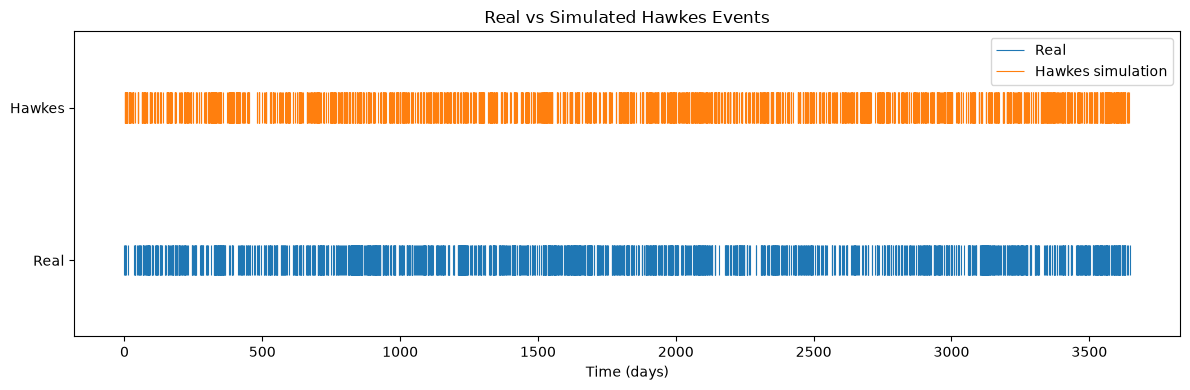

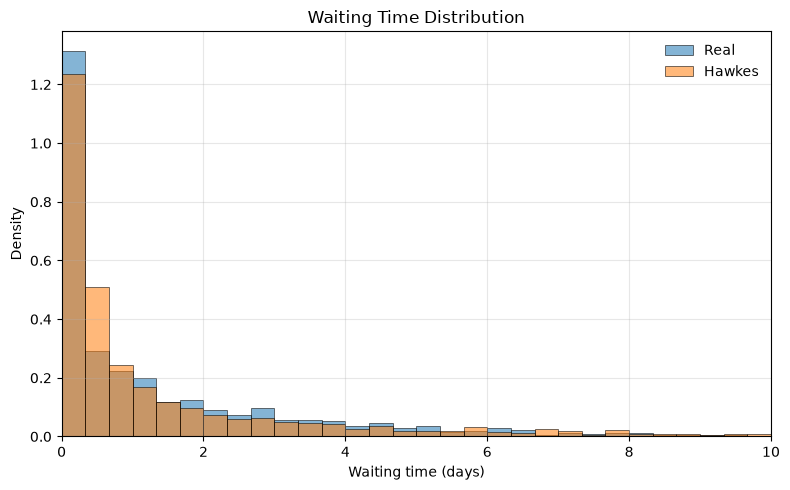


Branching ratio:
n = alpha/beta = 0.5357

Interpretation:
- n < 1 : stable Hawkes process
- larger n : stronger earthquake clustering


Conclusion:

The Poisson model assumes independent earthquakes with a
constant rate.

The Hawkes model allows earthquakes to trigger additional
events.

If Hawkes has:
- higher log likelihood,
- lower AIC/BIC,
- realistic simulations,

then the earthquake catalogue shows evidence of
self-excitation.



In [1]:
# ==============================================================
# Notebook 4: Poisson vs Hawkes Comparison
#
# Goal:
# - Compare Poisson and Hawkes models
# - Compare log-likelihoods
# - Compute AIC/BIC
# - Simulate Hawkes earthquakes
# - Check whether Hawkes reproduces clustering
#
# ==============================================================


# --------------------------------------------------------------
# 1. Imports
# --------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.hawkes import (
    hawkes_log_likelihood,
    simulate_hawkes
)


# --------------------------------------------------------------
# 2. Load earthquake data
# --------------------------------------------------------------

df = pd.read_csv(
    "../data/earthquakes_greece_2016_2026.csv"
)

df["time"] = pd.to_datetime(df["time"])

df = (
    df
    .sort_values("time")
    .reset_index(drop=True)
)


# --------------------------------------------------------------
# 3. Convert times to days
# --------------------------------------------------------------

t0 = df["time"].iloc[0]

times = (
    df["time"] - t0
).dt.total_seconds() / (24 * 3600)

times = times.values

T = times[-1]

N = len(times)


print("Number of earthquakes:", N)
print("Observation period:", T, "days")


# --------------------------------------------------------------
# 4. Poisson model
# --------------------------------------------------------------
#
# lambda(t) = lambda
#
# MLE:
#
# lambda_hat = N / T
#

lambda_hat = N / T


def poisson_loglikelihood(times, lam):

    N = len(times)
    T = times[-1]

    return (
        N * np.log(lam)
        -
        lam * T
    )


poisson_ll = poisson_loglikelihood(
    times,
    lambda_hat
)


print("\nPoisson model")
print("----------------")
print(f"lambda = {lambda_hat:.5f}")
print(f"log likelihood = {poisson_ll:.2f}")


# --------------------------------------------------------------
# 5. Load Hawkes parameters
# --------------------------------------------------------------

mu_hat, alpha_hat, beta_hat = np.load(
    "../data/hawkes_params.npy"
)


hawkes_ll = hawkes_log_likelihood(
    [
        mu_hat,
        alpha_hat,
        beta_hat
    ],
    times
)


print("\nHawkes model")
print("----------------")
print(f"mu    = {mu_hat:.5f}")
print(f"alpha = {alpha_hat:.5f}")
print(f"beta  = {beta_hat:.5f}")
print(f"log likelihood = {hawkes_ll:.2f}")


# --------------------------------------------------------------
# 6. AIC comparison
# --------------------------------------------------------------
#
# AIC = 2k - 2log(L)
#
# Lower is better.
#

aic_poisson = (
    2 * 1
    -
    2 * poisson_ll
)

aic_hawkes = (
    2 * 3
    -
    2 * hawkes_ll
)


print("\nAIC")
print("----------------")
print(f"Poisson AIC = {aic_poisson:.2f}")
print(f"Hawkes AIC  = {aic_hawkes:.2f}")


# --------------------------------------------------------------
# 7. BIC comparison
# --------------------------------------------------------------
#
# BIC = k log(N) - 2log(L)
#
#

bic_poisson = (
    1 * np.log(N)
    -
    2 * poisson_ll
)

bic_hawkes = (
    3 * np.log(N)
    -
    2 * hawkes_ll
)


print("\nBIC")
print("----------------")
print(f"Poisson BIC = {bic_poisson:.2f}")
print(f"Hawkes BIC  = {bic_hawkes:.2f}")


# --------------------------------------------------------------
# 8. Simulate Hawkes process
# --------------------------------------------------------------

np.random.seed(42)

hawkes_sim = simulate_hawkes(
    mu_hat,
    alpha_hat,
    beta_hat,
    T
)


print("\nSimulation")
print("----------------")
print("Real earthquakes:", N)
print("Simulated Hawkes earthquakes:", len(hawkes_sim))


# --------------------------------------------------------------
# 9. Timeline comparison
# --------------------------------------------------------------

plt.figure(figsize=(12,4))

plt.vlines(
    times,
    -0.1,
    0.1,
    linewidth=0.8,
    label="Real"
)

plt.vlines(
    hawkes_sim,
    0.9,
    1.1,
    linewidth=0.8,
    color="C1",
    label="Hawkes simulation"
)

plt.yticks(
    [0,1],
    ["Real", "Hawkes"]
)

plt.ylim(-0.5, 1.5)

plt.xlabel("Time (days)")
plt.title("Real vs Simulated Hawkes Events")

plt.legend(loc="upper right")

plt.tight_layout()
plt.savefig("../figures/04_real_vs_hawkes_timeline.png", dpi=150, bbox_inches="tight")
plt.show()


# --------------------------------------------------------------
# 10. Waiting-time comparison
# --------------------------------------------------------------

real_waiting = np.diff(times)

sim_waiting = np.diff(hawkes_sim)


# Cap the x-axis so the long tail of rare, multi-week gaps
# doesn't compress the interesting short-waiting-time region

WAITING_TIME_XLIM = 10
WAITING_TIME_BINS = 30

plt.figure(figsize=(8,5))

plt.hist(
    real_waiting,
    bins=WAITING_TIME_BINS,
    range=(0, WAITING_TIME_XLIM),
    density=True,
    alpha=0.55,
    color="C0",
    edgecolor="black",
    linewidth=0.7,
    label="Real"
)

plt.hist(
    sim_waiting,
    bins=WAITING_TIME_BINS,
    range=(0, WAITING_TIME_XLIM),
    density=True,
    alpha=0.55,
    color="C1",
    edgecolor="black",
    linewidth=0.7,
    label="Hawkes"
)

plt.xlabel("Waiting time (days)")
plt.ylabel("Density")

plt.title("Waiting Time Distribution")

plt.xlim(0, WAITING_TIME_XLIM)

plt.legend(frameon=False)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../figures/04_waiting_time_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


# --------------------------------------------------------------
# 11. Branching ratio
# --------------------------------------------------------------

branching_ratio = alpha_hat / beta_hat


print(
    f"""
Branching ratio:
n = alpha/beta = {branching_ratio:.4f}

Interpretation:
- n < 1 : stable Hawkes process
- larger n : stronger earthquake clustering
"""
)


# --------------------------------------------------------------
# Conclusion
# --------------------------------------------------------------

print("""
Conclusion:

The Poisson model assumes independent earthquakes with a
constant rate.

The Hawkes model allows earthquakes to trigger additional
events.

If Hawkes has:
- higher log likelihood,
- lower AIC/BIC,
- realistic simulations,

then the earthquake catalogue shows evidence of
self-excitation.
""")
